# Refresh Opportunity Ranking Under Temporal Shift

## Abstract

This study asks which already-visible content items should receive limited human refresh review before the next month. It aggregates the FlyRank pseudonymized warehouse into leakage-safe page-month examples. A fixed baseline, logistic regression, and random forest are compared with time-aware training, validation, and a one-time sealed test using Precision@50. The baseline wins validation, but the random forest reverses the order on the sealed month, revealing temporal instability rather than a universally superior method. The output is a ranked 50-item human-review queue with reasons, confidence, no-go rules, and monitoring triggers.

## 1. Introduction / problem statement

The decision is which content items deserve scarce editorial investigation first. One row is one pseudonymized content item at a monthly anchor. A false positive wastes review time and can prompt an unnecessary change; a false negative misses a measured decline opportunity. The score is decision support, not an automatic edit or a causal claim.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
while not (ROOT / 'work' / 'outputs').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
def receipt(name):
    return json.loads((ROOT / 'work' / 'outputs' / name).read_text(encoding='utf-8'))
contract = receipt('feature_contract.json')
baseline = receipt('baseline_metrics.json')
selection = receipt('model_selection.json')
final = receipt('final_metrics.json')
actions = receipt('action_summary.json')
audit = receipt('signal_audit.json')
print('Decision output:', actions['intended_use'])
print('Unit:', contract['unit_of_analysis'])
print('Primary metric:', final['primary_metric'])

Decision output: prioritize human content review
Unit: one pseudonymized content item at one monthly decision anchor
Primary metric: precision_at_50


## 2. Data

Release: flyrank_pseudonymized_warehouse_release_v20260703. The warehouse contains 104 pseudonymized clients, 519,606 content records, and 78,835,655 daily performance rows dated 2025-01-27 through 2026-06-30. Training anchors are September 2025–March 2026; April predicts May for validation; May predicts June for the sealed test. Eligibility requires 100 current impressions and 20 measured GSC days in both feature and outcome months. IDs are context only; names, domains, URLs, queries, titles, fixed-window query facts, provider fields, credentials, and all outcome-month features are excluded.

In [2]:
contract_table = pd.DataFrame(contract['fields'])
display(contract_table.groupby('bucket', observed=True).size().rename('fields').to_frame())
display(contract_table.loc[contract_table['bucket'].isin(['label', 'context', 'excluded'])])
print('Feature columns:', ', '.join(contract['feature_columns']))

,fields
bucket,
context,3
excluded,5
feature,15
label,2


,field,bucket,source_window,availability_rule
15,future_decline,label,next month,1 only when next-month impressions are below 8...
16,outcome_impressions,label,next month,label source only; never predictive
17,client_hash_id,context,stable pseudonym,"grouping, joins, and validation only"
18,content_hash_id,context,stable pseudonym,queue reference only; never predictive
19,month,context,feature month,time splitting only
20,raw names/domains/URLs/queries/titles,excluded,not used,private or identifying
21,all outcome-month fields,excluded,future,would leak the answer
22,IDs as model features,excluded,stable pseudonym,non-portable identity signal
23,provider_used/model_used,excluded,content metadata,not needed for the editorial decision
24,fact_content_query_90d,excluded,fixed rolling window,overlaps final outcomes and creates leakage risk


Feature columns: impressions, clicks, ctr, prior_impressions, prior_clicks, impression_momentum, avg_position, position_available, active_days, gsc_available_days, ga4_available_days, engaged_sessions, content_age_days, content_type, search_volume


## 3. Methodology

The label is one when next-month measured impressions fall below 80% of the feature month. The frozen baseline weights exposure (40%), negative prior momentum (30%), age (20%), and valid position opportunity (10%). Logistic regression and a 300-tree random forest use training-fitted imputation, missingness indicators, one-hot content type, and seed 42. Selection is validation-only; IDs and outcomes never enter predictive features.

In [3]:
method_summary = pd.DataFrame({
    'item': ['training rows', 'validation rows', 'selected method', 'learned comparison', 'random seed', 'sealed evaluated once'],
    'value': [selection['training_rows'], selection['validation_rows'], final['selected_method'], final['comparison_model'], selection['random_seed'], final['sealed_evaluated_once']],
})
display(method_summary)
assert selection['sealed_month_used'] is False
assert final['sealed_evaluated_once'] is True
print('Leakage protocol verified from committed receipts.')

,item,value
0,training rows,341546
1,validation rows,93474
2,selected method,fixed_baseline
3,learned comparison,random_forest
4,random seed,42
5,sealed evaluated once,True


Leakage protocol verified from committed receipts.


## 4. Results: baseline and model on identical rows

The fixed baseline was selected because it reached 66% validation Precision@50 versus 54% for the strongest learned comparison. On the one-time sealed month, the random forest reversed the order at 98% versus 68%. This reversal is evidence of temporal instability; it is not used for retuning and does not prove a causal refresh effect.

,split,method,rows,base_rate,precision_at_50,average_precision,recall_at_50,lift_at_50
0,validation,fixed_baseline,93474,53.79%,66%,53.34%,0.066%,1.23x
1,validation,random_forest,93474,53.79%,54%,60.42%,0.054%,1.00x
2,sealed,fixed_baseline,93048,64.04%,68%,67.02%,0.057%,1.06x
3,sealed,random_forest,93048,64.04%,98%,72.22%,0.082%,1.53x


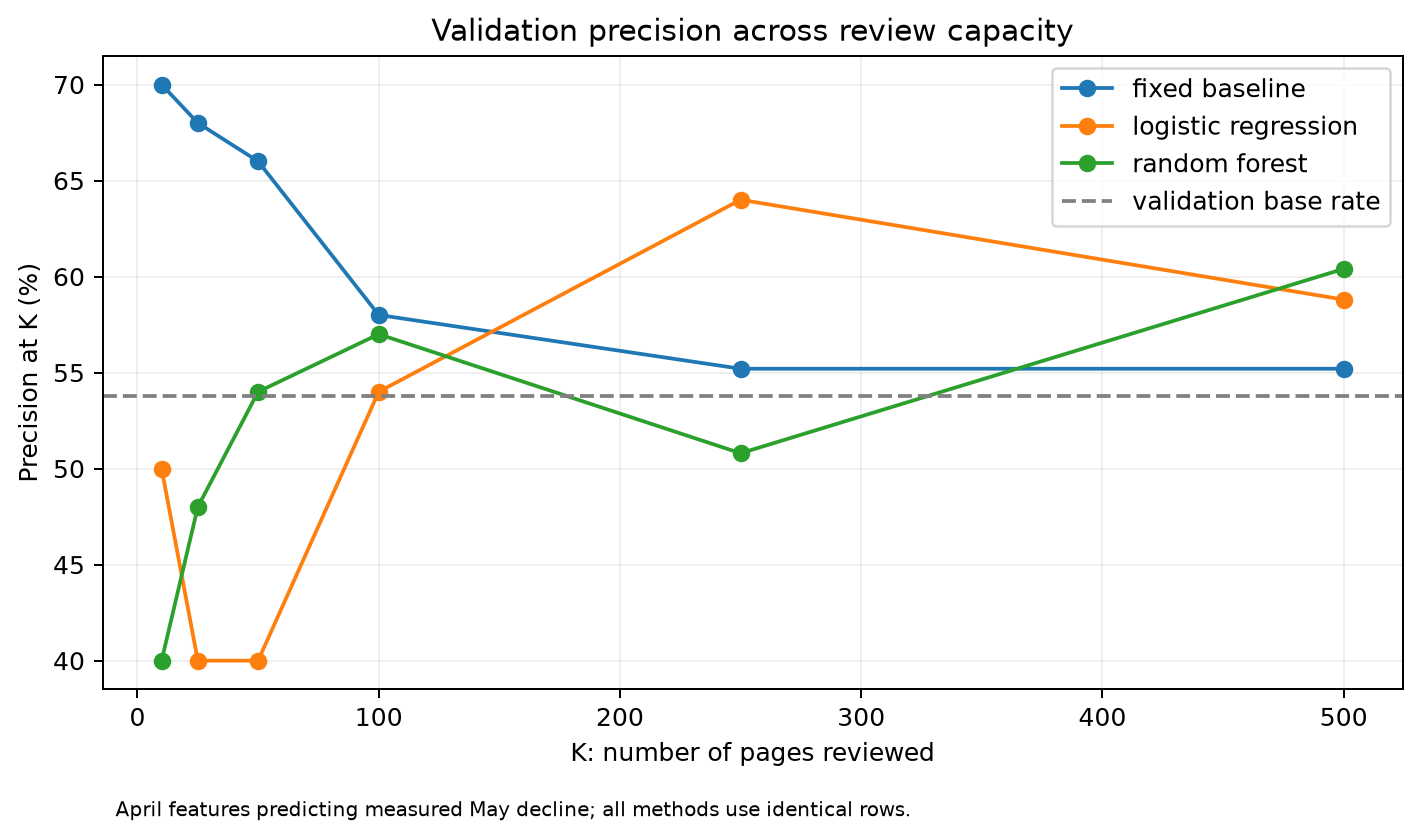

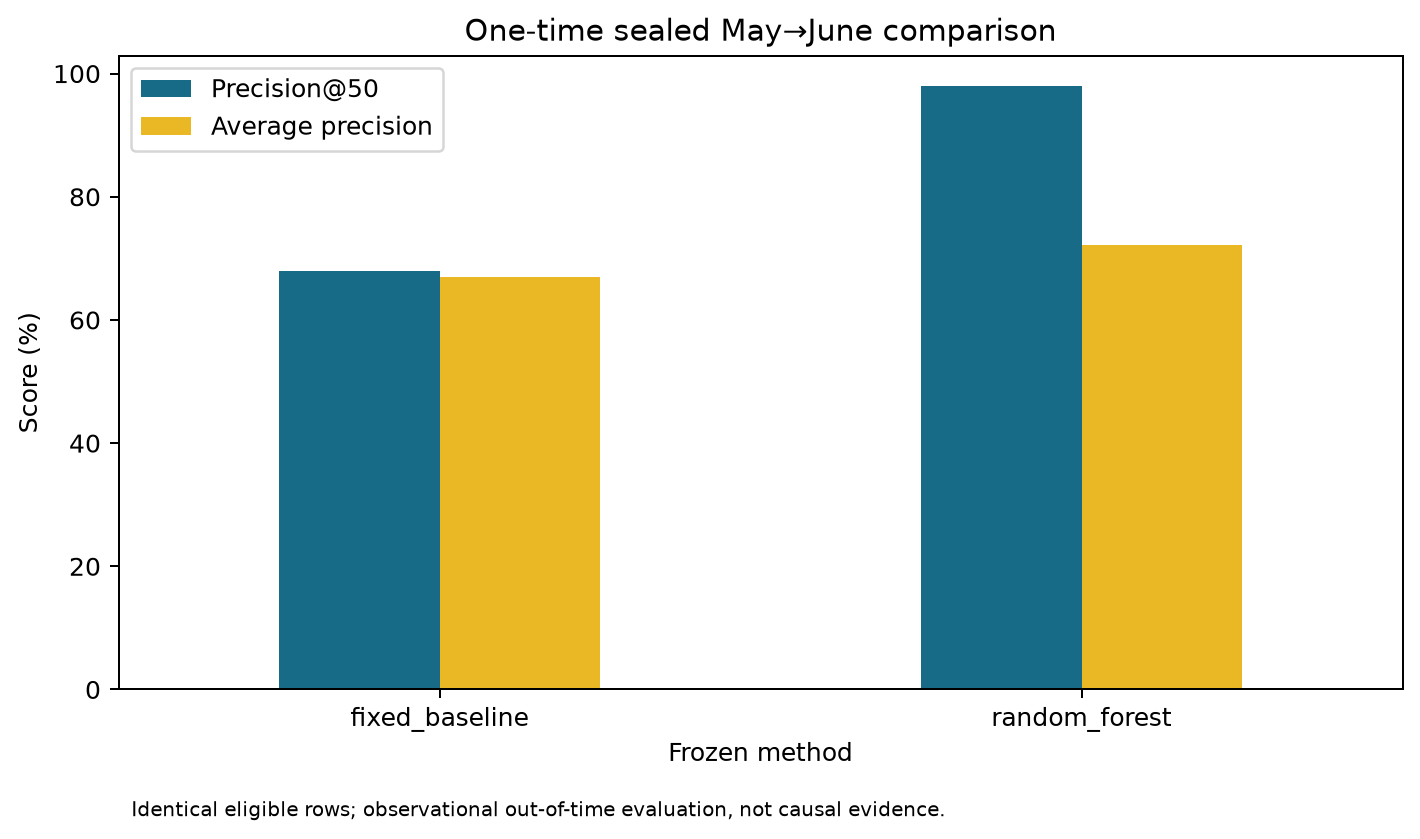

The learned comparison exceeded the validation-selected baseline on sealed Precision@50, showing temporal instability; the method is not retuned and claims remain directional.


In [4]:
rows = []
for split in ['validation', 'sealed']:
    for method, values in final[split].items():
        rows.append({
            'split': split, 'method': method, 'rows': values['rows'],
            'base_rate': values.get('positive_rate', selection['validation_positive_rate']),
            'precision_at_50': values['precision_at_50'], 'average_precision': values['average_precision'],
            'recall_at_50': values['recall_at_50'], 'lift_at_50': values['lift_at_50'],
        })
results = pd.DataFrame(rows)
display(results.style.format({'base_rate': '{:.2%}', 'precision_at_50': '{:.0%}', 'average_precision': '{:.2%}', 'recall_at_50': '{:.3%}', 'lift_at_50': '{:.2f}x'}))
display(Image(filename=str(ROOT / 'work' / 'figures' / 'validation_precision_at_k.png')))
display(Image(filename=str(ROOT / 'work' / 'figures' / 'sealed_month_comparison.png')))
print(final['claim_wording'])

## 5. Limitations and honest framing

The label is an observed search-visibility proxy, not a content-quality judgment or causal refresh effect. Base rates vary substantially by month; coverage filtering narrows applicability; seasonality and intent are incomplete; Precision@50 has very low recall in a large positive population; and one sealed reversal cannot establish a permanently superior model. Claims are measured, directional, and decision-support only.

In [5]:
display(pd.Series(final['limitations'], name='limitation').to_frame())
print('Client-grouped sealed average precision:')
display(pd.DataFrame(final['grouped_sealed_diagnostic']).T)

,limitation
0,temporal base-rate variation
1,observational label is not a causal refresh ef...
2,coverage filters narrow applicability
3,content intent and seasonality are not fully r...


Client-grouped sealed average precision:


,eligible_clients,macro_average_precision
fixed_baseline,40.0,0.514838
random_forest,40.0,0.574931


## 6. Ranked recommendations

Review the highest-ranked 50 items for intent, accuracy, coverage gaps, competing content, seasonality, tracking continuity, and business value. Protect growing pages; consolidate or prune only after explicit cannibalization review; monitor incomplete evidence. Never auto-edit, auto-delete, expose identifying data, infer Google's algorithm, or claim that a refresh caused movement.

,rank,content_hash_id,baseline_score,suggested_action,reason_codes,confidence_tier,impressions,impression_momentum,avg_position,position_available,content_age_days
0,1,content_8e1334d6356668e3,89.005243,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,17055,0.133146,10.855350,True,471
1,2,content_17608f489483f8f8,84.529596,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,8127,0.120307,9.489110,True,317
2,3,content_b86db4adb85772b5,84.456464,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,4449,0.142500,10.455383,True,412
3,4,content_9dcaefd5e410fa14,82.558643,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,17520,0.337280,8.728596,True,436
4,5,content_c46df0fa61530d86,82.229047,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,20844,0.366275,8.665323,True,436
5,6,content_8517581218d33225,82.090111,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,5148,0.117130,8.540404,True,317
6,7,content_e7536b365bedaf11,81.970849,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,8986,0.171820,5.496550,True,436
7,8,content_ba3f508f9d3ac24c,81.164633,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,6812,0.286749,9.100411,True,412
8,9,content_a2cf70fc33c61d71,80.720427,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,5640,0.295939,10.412234,True,412
9,10,content_c7d8ab552944f4f1,80.668849,refresh_or_expand_review,negative_prior_momentum;visible_position,high,1799,0.107692,12.142539,True,412


,top_50_rows
refresh_or_expand_review,50


,top_50_rows
medium,30
high,20


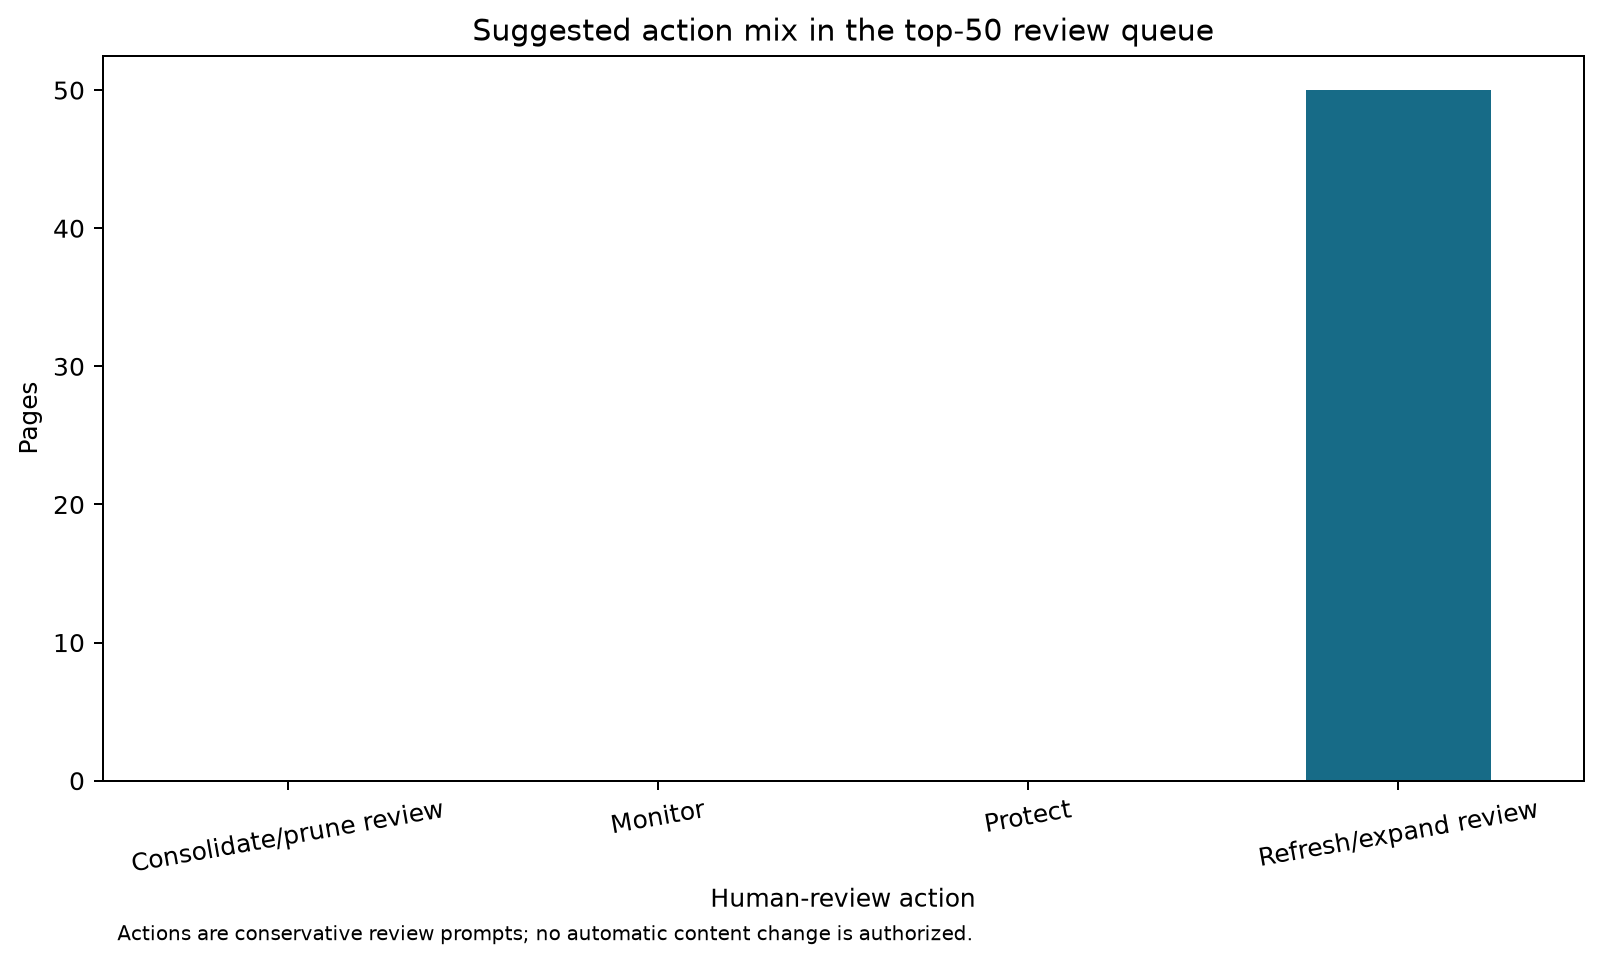

Monitoring triggers: base rate shift over 10 percentage points; key-feature missingness shift over 10 points; Precision@50 below contemporaneous base rate; warehouse schema or release change


In [6]:
queue_path = ROOT / 'work' / 'outputs' / 'final_ranked_queue.csv'
queue = pd.read_csv(queue_path)
assert list(queue.columns) == actions['public_queue_columns']
display(queue.head(10))
display(pd.Series(actions['action_counts'], name='top_50_rows').to_frame())
display(pd.Series(actions['confidence_counts'], name='top_50_rows').to_frame())
display(Image(filename=str(ROOT / 'work' / 'figures' / 'action_mix.png')))
print('Monitoring triggers:', '; '.join(actions['monitoring_triggers']))

## 7. Reproducibility

Authenticate to Hugging Face, install requirements, run work.scripts.build_monthly_features, then execute the feature, audit, baseline, model, validation, action, and capstone notebooks in order. Local Parquet/CSV caches remain ignored; tested code, executed notebooks, figures, and JSON metric receipts are committed. The full instructions and paper narrative live in work/capstone_report.md.

In [7]:
required_receipts = ['feature_contract.json', 'signal_audit.json', 'baseline_metrics.json', 'model_selection.json', 'final_metrics.json', 'action_summary.json']
receipt_check = pd.DataFrame({'receipt': required_receipts, 'exists': [(ROOT / 'work' / 'outputs' / name).exists() for name in required_receipts]})
display(receipt_check)
assert receipt_check['exists'].all()
print('Random seed:', selection['random_seed'])

,receipt,exists
0,feature_contract.json,True
1,signal_audit.json,True
2,baseline_metrics.json,True
3,model_selection.json,True
4,final_metrics.json,True
5,action_summary.json,True


Random seed: 42


## 8. Acknowledgments & data credit

[Built on the FlyRank ML Internship dataset](https://flyrank.ai).

## Closing: five-minute demo outline

1. 0:00–0:40 — decision, unit, and wrong-call cost.
2. 0:40–1:20 — data grain, windows, safety, and eligibility.
3. 1:20–2:10 — baseline, candidates, and Precision@50.
4. 2:10–3:10 — validation/sealed reversal and no retuning.
5. 3:10–4:20 — ranked queue, reasons, confidence, and no-go rules.
6. 4:20–5:00 — tests, receipts, notebooks, and deployed paper.

### Social-post cut

I built a leakage-safe refresh-opportunity ranking system on real pseudonymized search data. A transparent baseline beat learned models at validation Precision@50, but a random forest reversed that result on the sealed month—an honest reminder that temporal stability matters as much as a headline metric. The output is a reproducible 50-item human-review queue with reasons, confidence, monitoring rules, and no causal claims.

### Employer-facing summary

I turned 78.8 million daily search-performance rows into a tested monthly decision system and public research paper. I designed time-aware validation, leakage/privacy checks, a transparent baseline, learned comparisons, a one-time sealed audit, and a ranked action playbook. I reported the validation/sealed reversal without retuning, balancing modeling, operational action, and honest evidence.

## Self-check

- [x] All paper sections, executed evidence, and required closing material are present.
- [x] Metrics load from committed receipts and match the report.
- [x] No client names, domains, URLs, private queries, credentials, or causal claims appear.
- [x] Ranked recommendations require human review.
- [x] FlyRank data credit is linked.